In [ ]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("sumn2u/garbage-classification-v2")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.07G/1.07G [00:50<00:00, 22.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12
Contents of base_path (/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions):
['12']
Contents of path (/root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12):
['original', 'standardized_256', 'standardized_384']


Checking for image folders in: /root/.cache/kagglehub/datasets/sumn2u/garbage-classification-v2/versions/12/original
Found categories: ['cardboard', 'clothes', 'shoes', 'paper', 'trash', 'plastic', 'metal', 'glass', 'biological', 'battery']

Found 12259 image files in total. Displaying samples:


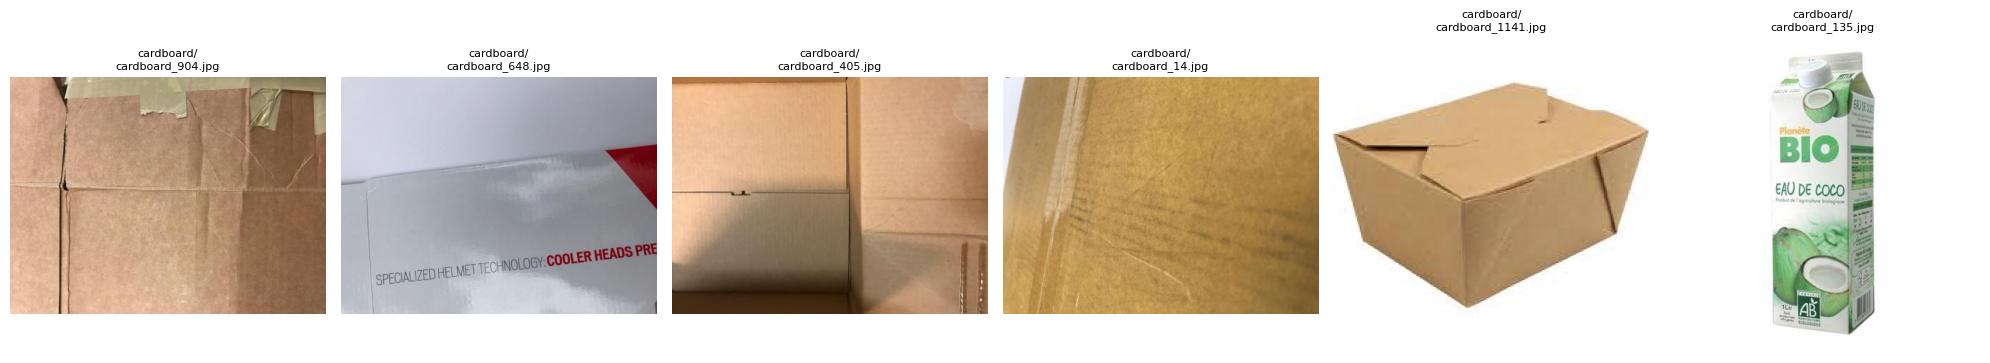

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory containing the images
image_root_dir = os.path.join(path, 'original')

print(f"Checking for image folders in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found.")
else:
    # Get the list of subdirectories (garbage categories)
    categories = [d for d in os.listdir(image_root_dir) if os.path.isdir(os.path.join(image_root_dir, d))]
    print(f"Found categories: {categories}")

    all_image_paths = []
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')

    # Scan through each category folder to find images
    for category in categories:
        category_path = os.path.join(image_root_dir, category)
        for root, dirs, files in os.walk(category_path):
            for file in files:
                if file.lower().endswith(image_extensions):
                    all_image_paths.append(os.path.join(root, file))

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying samples:")

        # Select samples from different folders to display
        samples_to_display = all_image_paths[:min(len(all_image_paths), 6)]

        fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
        if len(samples_to_display) == 1:
            axes = [axes]

        for i, img_path in enumerate(samples_to_display):
            try:
                img = Image.open(img_path)
                axes[i].imshow(img)
                # Show parent directory name (category) and filename
                category_name = os.path.basename(os.path.dirname(img_path))
                axes[i].set_title(f"{category_name}/\n{os.path.basename(img_path)}", fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo images found in the category folders.")

In [ ]:
import random

# Set seed for reproducibility
random.seed(42)

# Dictionary to store the split results
dataset_split = {
    'train': [],
    'test': []
}

train_ratio = 0.8

# Group images by category to ensure stratified split
category_images = {}
for img_path in all_image_paths:
    category = os.path.basename(os.path.dirname(img_path))
    if category not in category_images:
        category_images[category] = []
    category_images[category].append(img_path)

# Perform the split for each category
for category, images in category_images.items():
    random.shuffle(images)
    split_idx = int(len(images) * train_ratio)

    dataset_split['train'].extend(images[:split_idx])
    dataset_split['test'].extend(images[split_idx:])

print(f"Split complete:")
print(f"- Total images: {len(all_image_paths)}")
print(f"- Training set: {len(dataset_split['train'])} ({len(dataset_split['train'])/len(all_image_paths):.1%})")
print(f"- Test set: {len(dataset_split['test'])} ({len(dataset_split['test'])/len(all_image_paths):.1%})")

Split complete:
- Total images: 12259
- Training set: 9802 (80.0%)
- Test set: 2457 (20.0%)


In [ ]:
import tensorflow as tf

# Check GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Notebook Settings.')
else:
    print(f'Found GPU at: {device_name}')

# Verify physical devices
physical_devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))

Found GPU at: /device:GPU:0
Num GPUs Available:  1


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

# Prepare DataFrames for ImageDataGenerator
train_df = pd.DataFrame({'filename': dataset_split['train'], 'label': [os.path.basename(os.path.dirname(p)) for p in dataset_split['train']]})
test_df = pd.DataFrame({'filename': dataset_split['test'], 'label': [os.path.basename(os.path.dirname(p)) for p in dataset_split['test']]})

# Data Augmentation and Generators
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='training')
val_gen = datagen.flow_from_dataframe(train_df, x_col='filename', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', subset='validation')
test_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(test_df, x_col='filename', y_col='label', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

# Build InceptionV3 Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base layers for initial training

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(categories), activation='softmax')
])

model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
print("Starting training...")
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

Found 7842 validated image filenames belonging to 10 classes.
Found 1960 validated image filenames belonging to 10 classes.
Found 2457 validated image filenames belonging to 10 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Starting training...
Epoch 1/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 94s 292ms/step - accuracy: 0.8140 - loss: 0.5691 - val_accuracy: 0.4163 - val_loss: 6.7455
Epoch 2/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 48s 192ms/step - accuracy: 0.8917 - loss: 0.3325 - val_accuracy: 0.4189 - val_loss: 6.5174
Epoch 3/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 50s 204ms/step - accuracy: 0.9061 - loss: 0.2741 - val_accuracy: 0.4230 - val_loss: 7.4171
Epoch 4/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 47s 191ms/step - accuracy: 0.9149 - loss: 0.2389 - val_accuracy: 0.4184 - val_loss: 8.8315
Epoch 5/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 47s 189ms/step - accuracy: 0.9281 - loss: 0.2075 - val_accuracy: 0.4204 - val_loss: 8.4645
Epoch 6/10
246/246 ━━━━━━━━━━━━━━━━━━━━ 48s 193ms/step - accuracy: 0.9338 - loss: 0.183

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_gen)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Print model summary
model.summary()

77/77 ━━━━━━━━━━━━━━━━━━━━ 25s 322ms/step - accuracy: 0.8270 - loss: 2.5577

Test Accuracy: 0.8270
Test Loss: 2.5577


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,384,128 (89.20 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

 Optimizer params: 1,054,230 (4.02 MB)

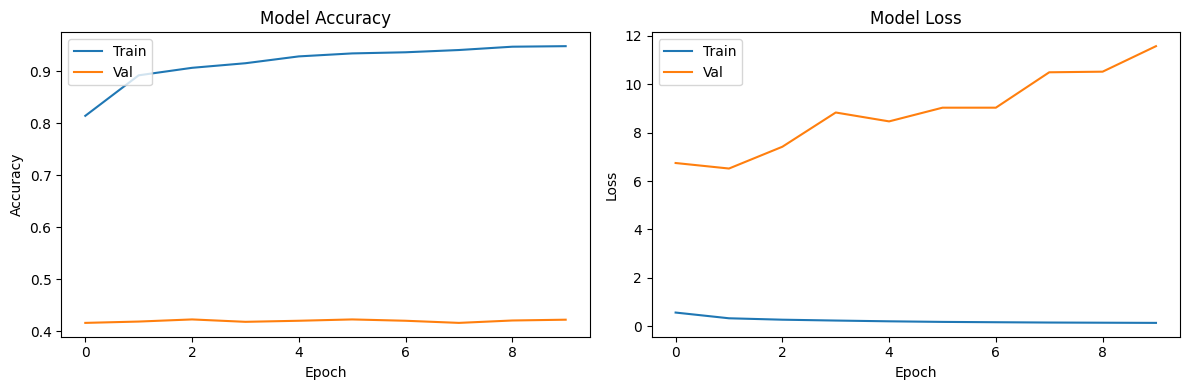

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')

plt.tight_layout()
plt.show()